In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

In [2]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [3]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


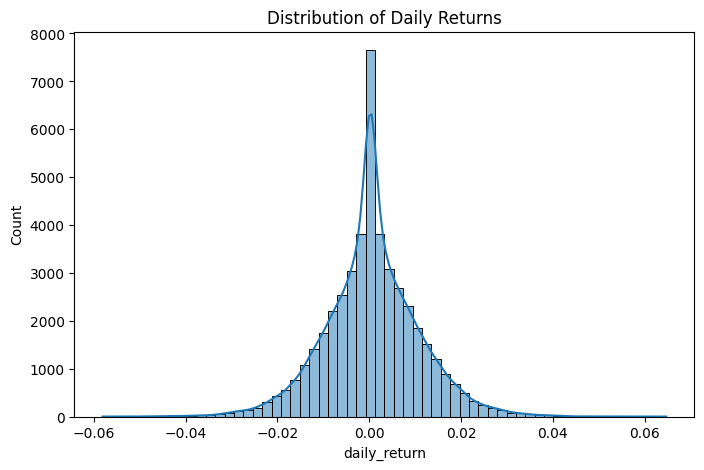

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=60,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.show()

In [5]:
def calculate_cagr(start_nav, end_nav, years):
    return (end_nav/start_nav)**(1/years)-1

In [6]:
cagr_list=[]

for code, df in nav.groupby("amfi_code"):

    df=df.sort_values("date")

    start=df.iloc[0]["nav"]
    end=df.iloc[-1]["nav"]

    years=(df["date"].max()-df["date"].min()).days/365

    cagr=calculate_cagr(start,end,years)

    cagr_list.append([code,cagr])

cagr_df=pd.DataFrame(
    cagr_list,
    columns=["amfi_code","CAGR"]
)

cagr_df.head()

,amfi_code,CAGR
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [7]:
rf=0.065

In [8]:
sharpe=[]

for code,df in nav.groupby("amfi_code"):

    r=df["daily_return"].dropna()

    mean=r.mean()*252

    std=r.std()*np.sqrt(252)

    sharpe_ratio=(mean-rf)/std

    sharpe.append([code,sharpe_ratio])

sharpe_df=pd.DataFrame(
    sharpe,
    columns=["amfi_code","Sharpe"]
)

sharpe_df

,amfi_code,Sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661
5,101208,-0.815567
6,102885,0.817099
7,102886,-0.205832
8,102887,0.619518
9,118632,1.081659


In [9]:
sortino=[]

for code,df in nav.groupby("amfi_code"):

    r=df["daily_return"].dropna()

    downside=r[r<0]

    downside_std=downside.std()*np.sqrt(252)

    annual_return=r.mean()*252

    ratio=(annual_return-rf)/downside_std

    sortino.append([code,ratio])

sortino_df=pd.DataFrame(
    sortino,
    columns=["amfi_code","Sortino"]
)

In [10]:
sortino=[]

for code,df in nav.groupby("amfi_code"):

    r=df["daily_return"].dropna()

    downside=r[r<0]

    downside_std=downside.std()*np.sqrt(252)

    annual_return=r.mean()*252

    ratio=(annual_return-rf)/downside_std

    sortino.append([code,ratio])

sortino_df=pd.DataFrame(
    sortino,
    columns=["amfi_code","Sortino"]
)

sortino_df.head()

,amfi_code,Sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [11]:
benchmark = benchmark.sort_values("date")

nifty = benchmark[
    benchmark["index_name"]=="Nifty 100"
].copy()

nifty["benchmark_return"] = nifty["close_value"].pct_change()

In [12]:
alpha_beta=[]

for code,df in nav.groupby("amfi_code"):

    temp=df.merge(
        nifty[["date","benchmark_return"]],
        on="date",
        how="inner"
    )

    temp=temp.dropna()

    if len(temp)>30:

        beta,alpha,r,p,std = linregress(
            temp["benchmark_return"],
            temp["daily_return"]
        )

        alpha = alpha*252

        alpha_beta.append(
            [code,alpha,beta]
        )

alpha_beta_df=pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "Alpha",
        "Beta"
    ]
)

alpha_beta_df.head()

,amfi_code,Alpha,Beta


In [13]:
drawdowns=[]

for code,df in nav.groupby("amfi_code"):

    df=df.sort_values("date")

    running_max=df["nav"].cummax()

    dd=df["nav"]/running_max-1

    drawdowns.append([
        code,
        dd.min()
    ])

drawdown_df=pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "Max_Drawdown"
    ]
)

drawdown_df.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [14]:
scorecard = (
    cagr_df
    .merge(sharpe_df,on="amfi_code")
    .merge(sortino_df,on="amfi_code")
    .merge(alpha_beta_df,on="amfi_code")
    .merge(drawdown_df,on="amfi_code")
)

scorecard = scorecard.merge(
    performance[
        [
            "amfi_code",
            "expense_ratio_pct"
        ]
    ],
    on="amfi_code"
)

scorecard["Score"] = (

    scorecard["CAGR"].rank(pct=True)*30

    +

    scorecard["Sharpe"].rank(pct=True)*25

    +

    scorecard["Alpha"].rank(pct=True)*20

    +

    (1-scorecard["expense_ratio_pct"].rank(pct=True))*15

    +

    (1-scorecard["Max_Drawdown"].rank(pct=True))*10

)

scorecard = scorecard.sort_values(
    "Score",
    ascending=False
)

scorecard.head()

,amfi_code,CAGR,Sharpe,Sortino,Alpha,Beta,Max_Drawdown,expense_ratio_pct,Score


In [15]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

C:\Users\bhosl\AppData\Local\Temp\ipykernel_19628\2700013542.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


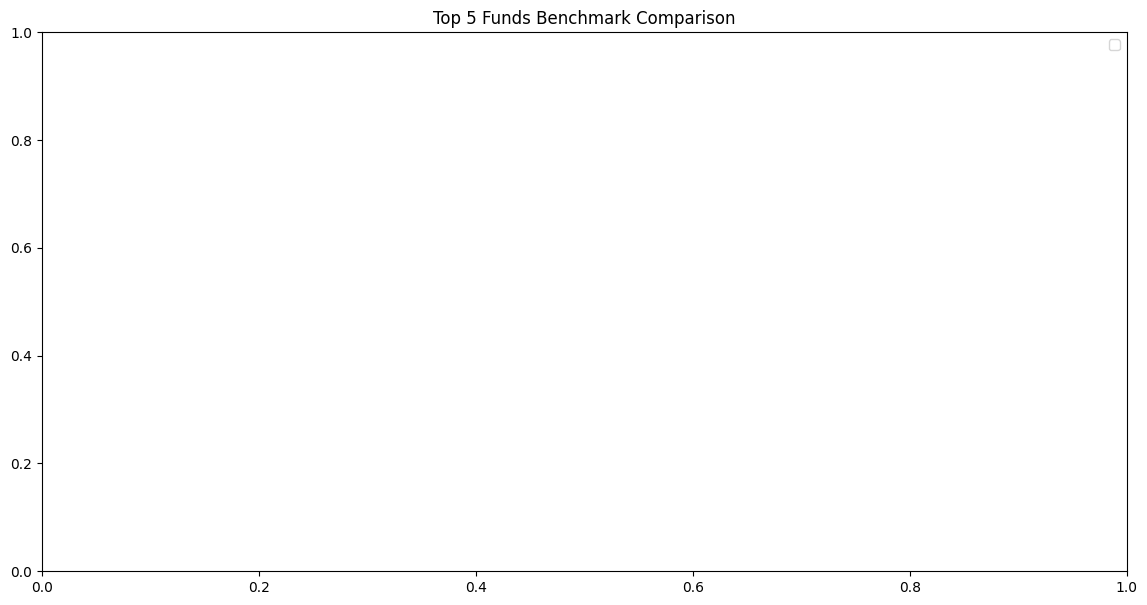

In [16]:
top5 = scorecard.head(5)["amfi_code"]

plt.figure(figsize=(14,7))

for code in top5:

    temp = nav[
        nav["amfi_code"]==code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.legend()

plt.title(
    "Top 5 Funds Benchmark Comparison"
)

plt.savefig(
    "../reports/charts/benchmark_comparison.png"
)

plt.show()